<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MontesDeOca-Andres-DL-TP2-Co24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## Data Load

In [1]:
# Librerias
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

custom_palette = {'<=50K': '#ff9999', '>50K': '#add8e6'}

In [2]:
# Enlace a la carpeta de Google Drive
folder_url = 'https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln'

# Descargar la carpeta completa en un directorio específico llamado 'dataset'
print("Descargando archivos desde Google Drive...")
gdown.download_folder(folder_url, output='dataset', quiet=True, use_cookies=False)

# Cargar los archivos directamente en las variables train y test
train = pd.read_csv('dataset/adult_train.csv')
test = pd.read_csv('dataset/adult_val.csv')

Descargando archivos desde Google Drive...


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [3]:
# Train

print(train.info())
display(train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital-status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital-gain    30162 non-null  int64 
 9   capital-loss    30162 non-null  int64 
 10  hours-per-week  30162 non-null  int64 
 11  skill-profile   30162 non-null  object
 12  native-country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(4), object(10)
memory usage: 3.2+ MB
None


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [4]:
# Test

print(test.info())
display(test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15060 entries, 0 to 15059
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             15060 non-null  int64 
 1   workclass       15060 non-null  object
 2   education       15060 non-null  object
 3   marital-status  15060 non-null  object
 4   occupation      15060 non-null  object
 5   relationship    15060 non-null  object
 6   race            15060 non-null  object
 7   sex             15060 non-null  object
 8   capital-gain    15060 non-null  int64 
 9   capital-loss    15060 non-null  int64 
 10  hours-per-week  15060 non-null  int64 
 11  skill-profile   15060 non-null  object
 12  native-country  15060 non-null  object
 13  income          15060 non-null  object
dtypes: int64(4), object(10)
memory usage: 1.6+ MB
None


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,security_patrol_basic,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,trade_cnc_operation,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,transport_commercial_driving,United-States,>50K
4,34,Private,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,personal_care_assistance,United-States,<=50K


- 30K registros en Train y 15K resitros en Test
- No hay nulos

### Income (Target)

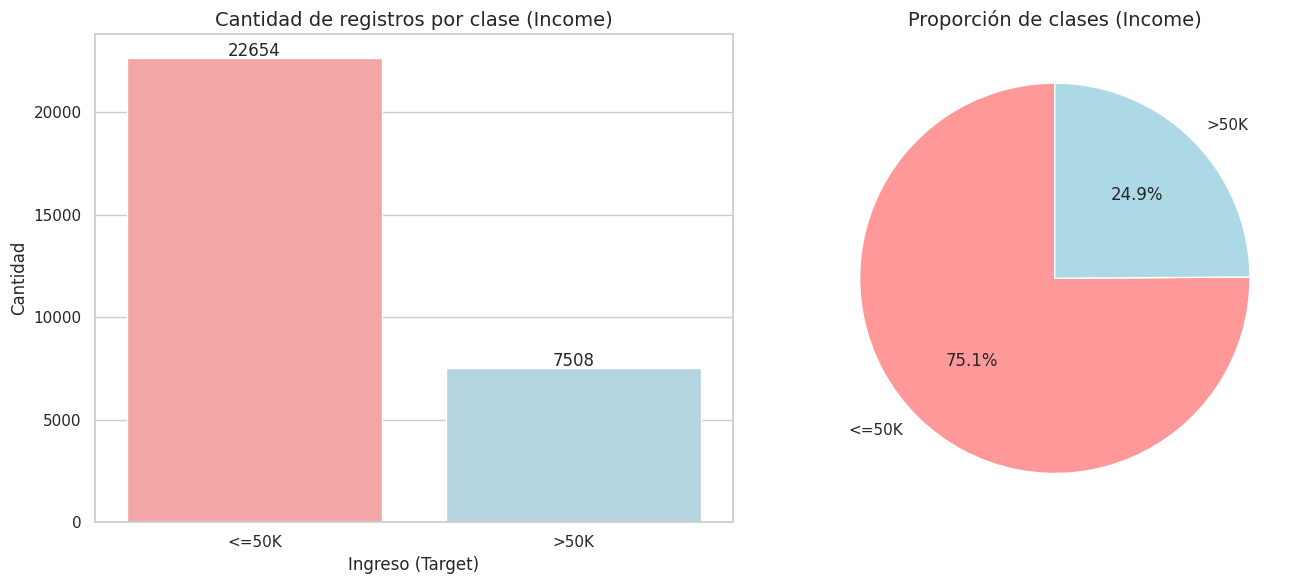

In [40]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de barras (Countplot)
# Se agrega hue='income' y legend=False para evitar el FutureWarning de Seaborn
sns.countplot(data=train, x='income', ax=axes[0], hue='income', palette=custom_palette, legend=False)
axes[0].set_title('Cantidad de registros por clase (Income)', fontsize=14)
axes[0].set_xlabel('Ingreso (Target)', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)

# Agregar los valores exactos sobre las barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Gráfico de torta (Pie chart)
income_counts = train['income'].value_counts()
# Mapeamos los colores desde custom_palette respetando el orden del índice
pie_colors = [custom_palette[val] for val in income_counts.index]
axes[1].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', startangle=90, colors=pie_colors)
axes[1].set_title('Proporción de clases (Income)', fontsize=14)

plt.tight_layout()
plt.show()

- Defino la Clase Positiva como >50K
- Un poco desbalanceada 25%

In [6]:
# 1. Transformación Variable Target (income) -> TAR_income

target_mapping = {'<=50K': 0, '>50K': 1}

TAR_income_train = train['income'].map(target_mapping).astype(int)
TAR_income_test = test['income'].map(target_mapping).astype(int)

# Asignamos el nombre a la serie para consistencia
TAR_income_train.name = 'TAR_income'
TAR_income_test.name = 'TAR_income'

- Transformo el Target a INT 0/1 para el entrenamiento del modelo
- TAR_income

### Age

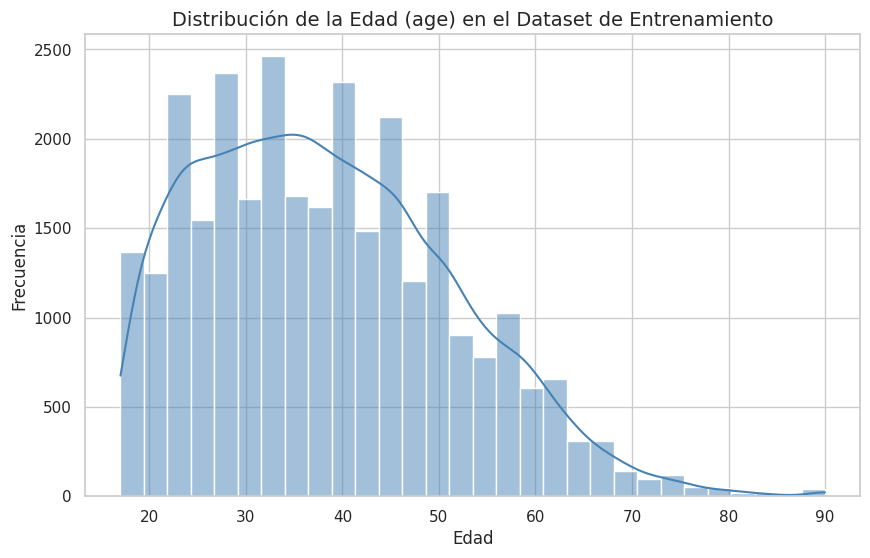


Estadísticas descriptivas de la variable 'age':


,age
count,30162.000000
mean,38.437902
std,13.134665
min,17.000000
25%,28.000000
50%,37.000000
75%,47.000000
max,90.000000


In [7]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear el histograma para la variable 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='age', bins=30, kde=True, color='steelblue')
plt.title('Distribución de la Edad (age) en el Dataset de Entrenamiento', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

# Mostrar estadísticas descriptivas de la variable 'age'
print("\nEstadísticas descriptivas de la variable 'age':")
display(train['age'].describe())

- Distribucion bastante simetrica centrada en 38/37 años (media/mediana)
- Arranca en 17 y termina en 90. Talvez se pueda capear los valores maximos?

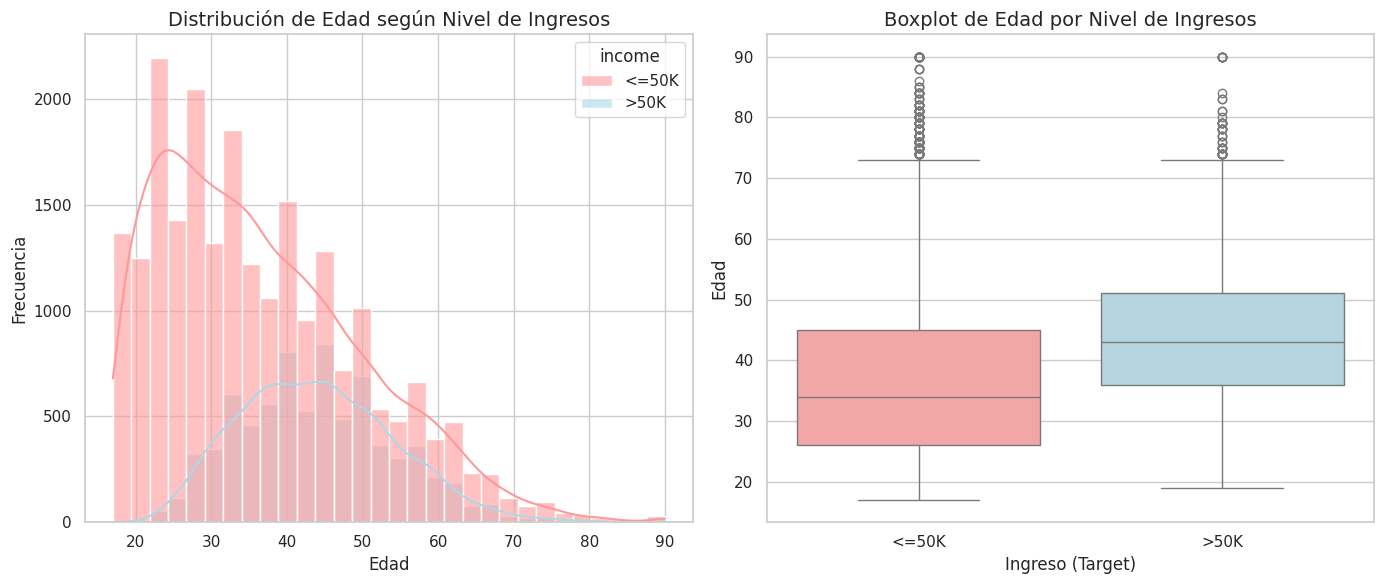

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,22654.0,36.60806,13.464631,17.0,26.0,34.0,45.0,90.0
>50K,7508.0,43.95911,10.269633,19.0,36.0,43.0,51.0,90.0


In [44]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='age', hue='income', bins=30, kde=True, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Edad según Nivel de Ingresos', fontsize=14)
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Edad por clase (Income)
# Se asigna hue='income' y legend=False para evitar warnings de seaborn
sns.boxplot(data=train, x='income', y='age', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Edad por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Edad', fontsize=12)

plt.tight_layout()
plt.show()

display(train.groupby('income')['age'].describe())

- Se observa como la distribucion de la edad para el segmento de mayores ingresos es mas simetrica y centrada en 43 años, considerablmente mayor a la distribucion del Universo

In [9]:
# 2. Transformación Age -> SCA_age
upper_limit = train['age'].quantile(0.99)

# Aplicamos clipping
age_train_clipped = train['age'].clip(upper=upper_limit).values.reshape(-1, 1)
age_test_clipped = test['age'].clip(upper=upper_limit).values.reshape(-1, 1)

scaler_age = MinMaxScaler()

# Guardamos como Series independientes con el nuevo nombre SCA_age
SCA_age_train = pd.Series(scaler_age.fit_transform(age_train_clipped).flatten(), index=train.index, name='SCA_age')
SCA_age_test = pd.Series(scaler_age.transform(age_test_clipped).flatten(), index=test.index, name='SCA_age')

print("Series 'SCA_age' creadas exitosamente:")
print(f"Train shape: {SCA_age_train.shape}")
display(SCA_age_train.describe())

Series 'SCA_age' creadas exitosamente:
Train shape: (30162,)


,SCA_age
count,30162.000000
mean,0.388678
std,0.235509
min,0.000000
25%,0.200000
50%,0.363636
75%,0.545455
max,1.000000


- Capeamos al percentil 99 para limitar el impacto que puedan ocacionar los registros con valores extremos (gente de 90 años)
- Ya que la idea es utilizar una Red Neuronal, y que sabemos que no hay valores exteremos, Escalamos los datos entre 0 y 1 utilizando MinMax Scaler
- SCA_age

### Workclass
Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

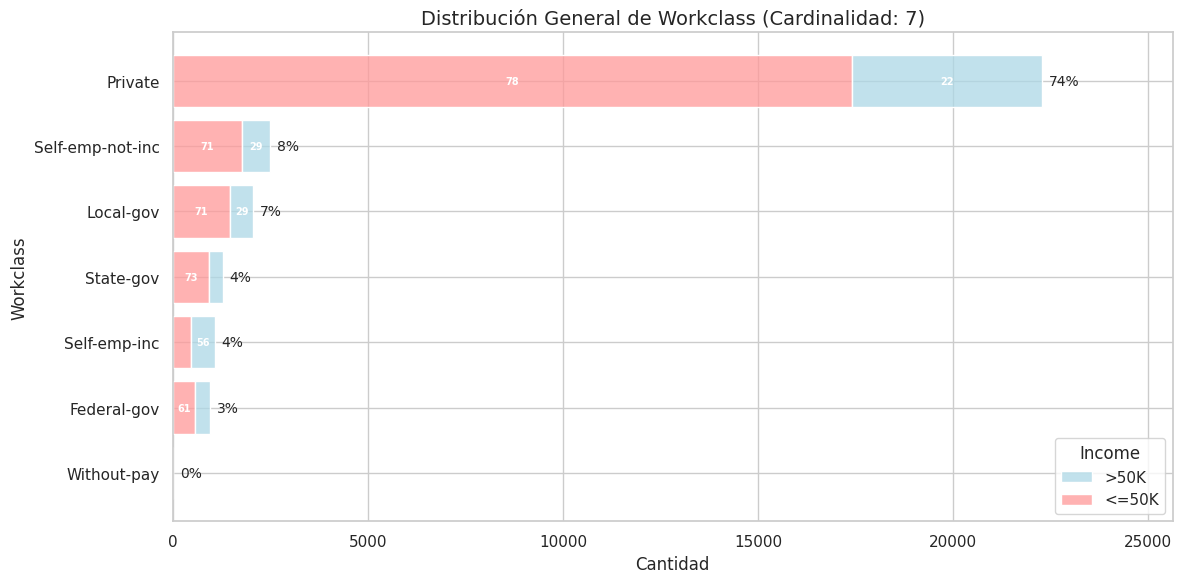

In [10]:
cardinalidad_workclass = train['workclass'].nunique()
conteo_workclass = train['workclass'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos temporalmente para el gráfico
train['workclass'] = pd.Categorical(train['workclass'], categories=conteo_workclass.index, ordered=True)

sns.histplot(data=train, y='workclass', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Workclass (Cardinalidad: {cardinalidad_workclass})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Workclass', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_workclass.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_workclass):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_workclass.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['workclass'] = train['workclass'].astype(object)
plt.tight_layout()
plt.show()

- Carnilaidad de 7. Probar one-hot y embeddings
- La gran mayoría de las personas trabajan en el sector privado (`Private`).
- Que hacemos con "Without-pay"?
- Proporcionalmente, los trabajadores independientes registrados y los federales, son los que tienen la mayor tasa de buenos

In [11]:
from sklearn.preprocessing import OneHotEncoder

# 3. Transformación Workclass -> OHE_workclass
# Instanciamos el encoder
ohe_workclass = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos con train y transformamos ambos
workclass_ohe_train_raw = ohe_workclass.fit_transform(train[['workclass']])
workclass_ohe_test_raw = ohe_workclass.transform(test[['workclass']])

# Obtenemos las categorías originales para nombrar las columnas sin el prefijo repetido
categories = [cat.replace(' ', '_') for cat in ohe_workclass.categories_[0]]
columns_ohe = [f"OHE_{cat}" for cat in categories]

# Creamos los DataFrames resultantes
OHE_workclass_train = pd.DataFrame(workclass_ohe_train_raw, columns=columns_ohe, index=train.index)
OHE_workclass_test = pd.DataFrame(workclass_ohe_test_raw, columns=columns_ohe, index=test.index)

print("Variables One-Hot para 'workclass' creadas (nombres limpios):")
display(OHE_workclass_train.head())

Variables One-Hot para 'workclass' creadas (nombres limpios):


,OHE_Federal-gov,OHE_Local-gov,OHE_Private,OHE_Self-emp-inc,OHE_Self-emp-not-inc,OHE_State-gov,OHE_Without-pay
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Education
Nivel educativo alcanzado del individuo.

In [12]:
# Recargamos la columna original para evitar los NaN generados por el re-mapeo
temp_train = pd.read_csv('dataset/adult_train.csv')
temp_test = pd.read_csv('dataset/adult_val.csv')
train['education'] = temp_train['education']
test['education'] = temp_test['education']

education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']
education_mapping = {edu: f'{i+1:02d}-{edu}' for i, edu in enumerate(education_order)}

# Aplicamos el mapeo ordinal
train['education'] = train['education'].map(education_mapping)
test['education'] = test['education'].map(education_mapping)

# Definimos el orden para los graficos basado en los nuevos strings
order_edu = sorted(train['education'].unique())
cardinalidad_edu = train['education'].nunique()

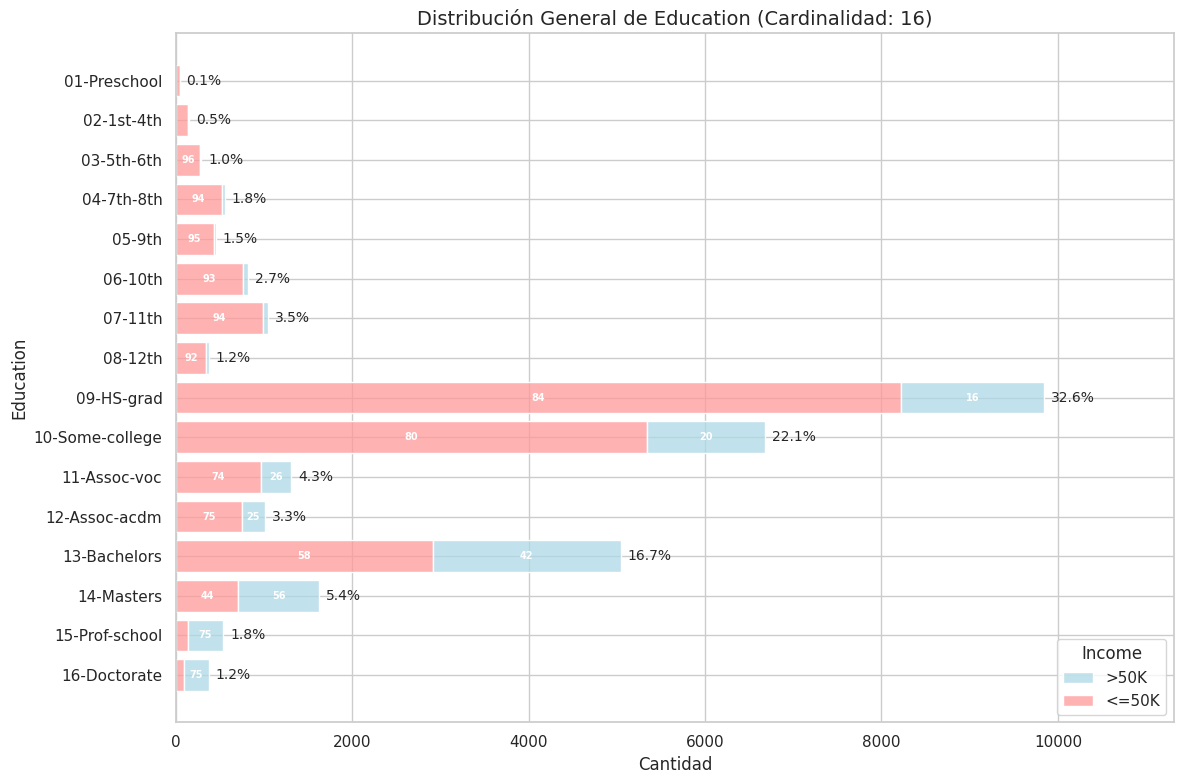

In [13]:
conteo_education = train['education'].value_counts().reindex(order_edu)
fig, ax = plt.subplots(figsize=(12, 8))
train['education'] = pd.Categorical(train['education'], categories=order_edu, ordered=True)

sns.histplot(data=train, y='education', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Education (Cardinalidad: {cardinalidad_edu})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Education', fontsize=12)

sns.move_legend(ax, 'lower right', title='Income')

# Anotaciones externas (% del total)
ax.set_xlim(0, conteo_education.max() * 1.15)
total_records = len(train)
for i, width in enumerate(conteo_education):
    percentage = f'{100 * width / total_records:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Anotaciones internas (% de la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_education):
            total_bar = conteo_education.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

train['education'] = train['education'].astype(object)
plt.tight_layout()
plt.show()

- Se actualizaron los valores de la variable y se hicieron ordinales

In [14]:
# 4. Transformación Education -> ORD_education
# Creamos un mapeo inverso desde los strings con prefijo (order_edu) a enteros (0 a 15)
ord_mapping = {val: i for i, val in enumerate(order_edu)}

ORD_education_train = train['education'].map(ord_mapping).astype(int)
ORD_education_test = test['education'].map(ord_mapping).astype(int)

# Asignamos nombre para consistencia
ORD_education_train.name = 'ORD_education'
ORD_education_test.name = 'ORD_education'

print("Series ordinales para 'education' creadas:")
print(f"Mapeo utilizado: {ord_mapping}")
display(ORD_education_train.head())

Series ordinales para 'education' creadas:
Mapeo utilizado: {'01-Preschool': 0, '02-1st-4th': 1, '03-5th-6th': 2, '04-7th-8th': 3, '05-9th': 4, '06-10th': 5, '07-11th': 6, '08-12th': 7, '09-HS-grad': 8, '10-Some-college': 9, '11-Assoc-voc': 10, '12-Assoc-acdm': 11, '13-Bachelors': 12, '14-Masters': 13, '15-Prof-school': 14, '16-Doctorate': 15}


,ORD_education
0,12
1,12
2,8
3,6
4,12


### Marital-status
Estado civil del individuo.

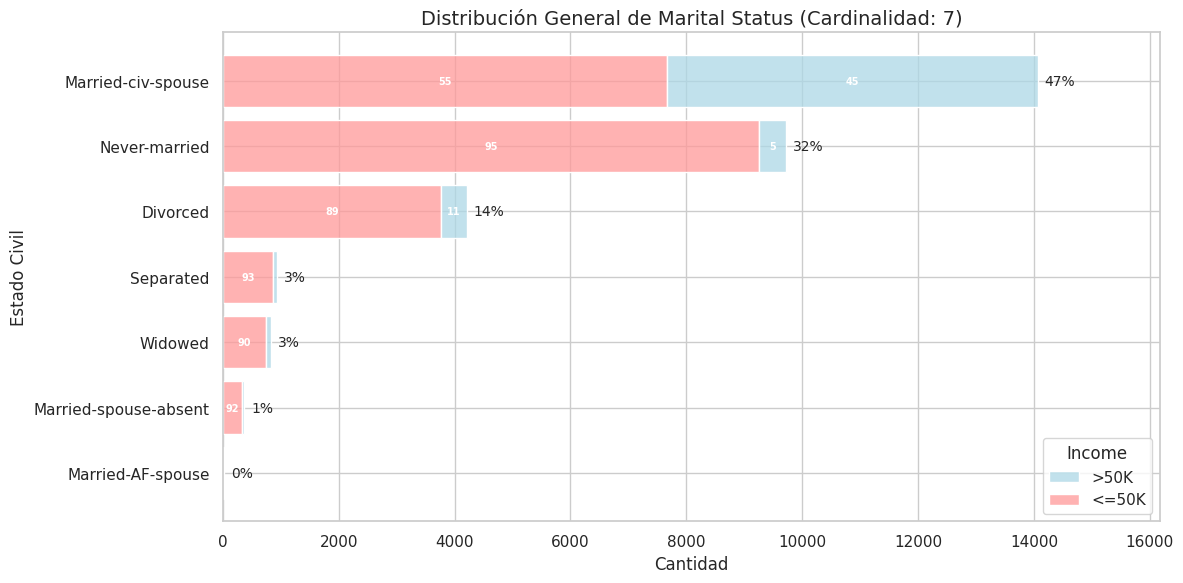

In [15]:
cardinalidad_marital = train['marital-status'].nunique()
conteo_marital = train['marital-status'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos temporalmente para el gráfico
train['marital-status'] = pd.Categorical(train['marital-status'], categories=conteo_marital.index, ordered=True)

sns.histplot(data=train, y='marital-status', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Marital Status (Cardinalidad: {cardinalidad_marital})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Estado Civil', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_marital.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_marital):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_marital.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['marital-status'] = train['marital-status'].astype(object)
plt.tight_layout()
plt.show()

- **Baja Cardinalidad:** 7 categorías.
- **Variable Nominal:** No existe un orden jerárquico lógico.
- **Importancia:** Permite capturar de forma independiente el fuerte impacto que tiene el estado 'Married-civ-spouse' en la variable target.

In [16]:
from sklearn.preprocessing import OneHotEncoder

# 5. Transformación Marital-status -> OHE_marital_status
ohe_marital = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
marital_ohe_train_raw = ohe_marital.fit_transform(train[['marital-status']])
marital_ohe_test_raw = ohe_marital.transform(test[['marital-status']])

# Nombres limpios
categories_marital = [cat.replace(' ', '_') for cat in ohe_marital.categories_[0]]
columns_ohe_marital = [f"OHE_{cat}" for cat in categories_marital]

# DataFrames
OHE_marital_train = pd.DataFrame(marital_ohe_train_raw, columns=columns_ohe_marital, index=train.index)
OHE_marital_test = pd.DataFrame(marital_ohe_test_raw, columns=columns_ohe_marital, index=test.index)

print("Variables One-Hot para 'marital-status' creadas:")
display(OHE_marital_train.head())

Variables One-Hot para 'marital-status' creadas:


,OHE_Divorced,OHE_Married-AF-spouse,OHE_Married-civ-spouse,OHE_Married-spouse-absent,OHE_Never-married,OHE_Separated,OHE_Widowed
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0


- Cardinalidad de 7, pensar disintas opciones
- Billetera Mata Galan:  Las personas casadas (`Married-civ-spouse`) tienen una proporción significativamente mayor de ingresos >50K en comparación con el resto de las categorías.

### Occupation
Tipo de ocupación o área laboral.

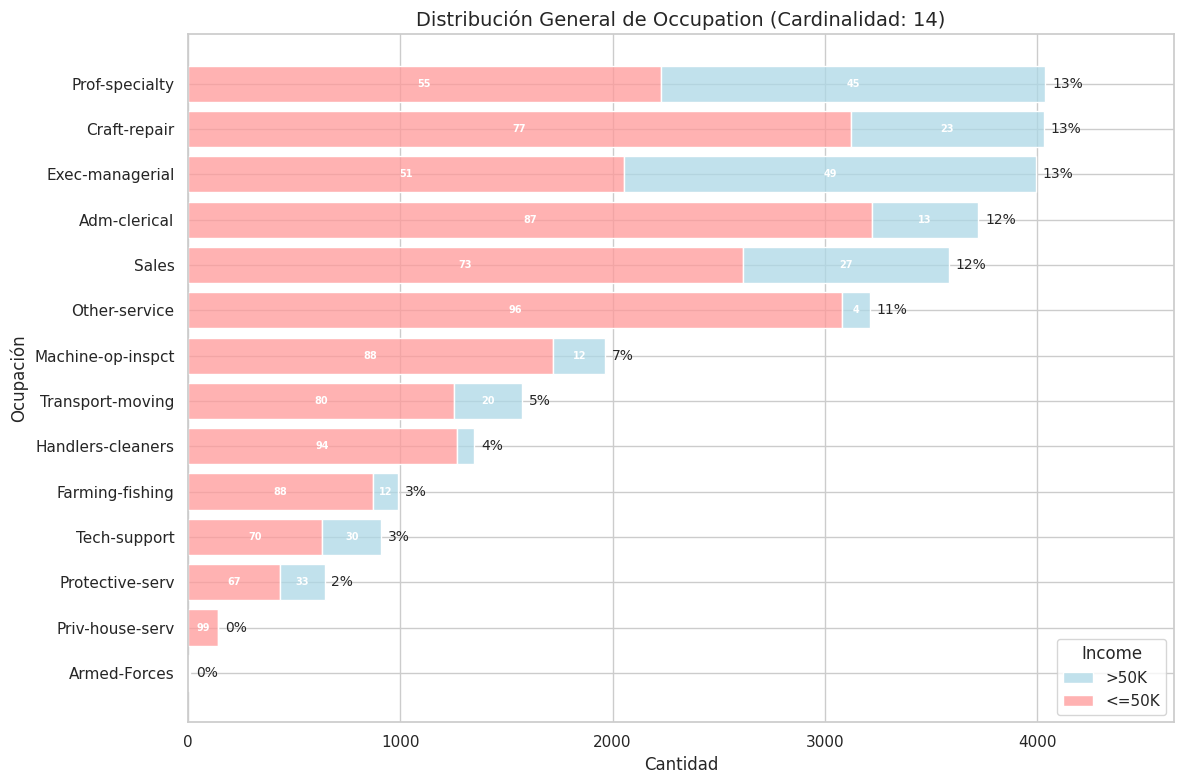

In [17]:
cardinalidad_occupation = train['occupation'].nunique()
conteo_occupation = train['occupation'].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
# Ordenamos temporalmente para el gráfico
train['occupation'] = pd.Categorical(train['occupation'], categories=conteo_occupation.index, ordered=True)

sns.histplot(data=train, y='occupation', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Occupation (Cardinalidad: {cardinalidad_occupation})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Ocupación', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_occupation.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_occupation):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_occupation.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['occupation'] = train['occupation'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 14, Embeddings

In [18]:
# Implementación de Frequency Encoding para 'occupation'

# 1. Calculamos las frecuencias (proporciones) en el set de entrenamiento
occ_freq_map = train['occupation'].value_counts(normalize=True).to_dict()

# 2. Aplicamos el mapeo a ambos datasets
# Usamos el prefijo 'FRE_' para identificar la transformación
FRE_occupation_train = train['occupation'].map(occ_freq_map)
FRE_occupation_test = test['occupation'].map(occ_freq_map)

# Manejo de valores nuevos en test (si los hubiera) con 0
FRE_occupation_test = FRE_occupation_test.fillna(0)

# Convertimos a Series con nombre para consistencia
FRE_occupation_train.name = 'FRE_occupation'
FRE_occupation_test.name = 'FRE_occupation'

print("Mapeo de frecuencias generado:")
for occ, freq in list(occ_freq_map.items())[:5]:
    print(f" - {occ}: {freq:.4f}")

display(FRE_occupation_train.to_frame().head())

Mapeo de frecuencias generado:
 - Prof-specialty: 0.1339
 - Craft-repair: 0.1336
 - Exec-managerial: 0.1324
 - Adm-clerical: 0.1234
 - Sales: 0.1188


,FRE_occupation
0,0.123367
1,0.132352
2,0.044758
3,0.044758
4,0.133877


### Relationship


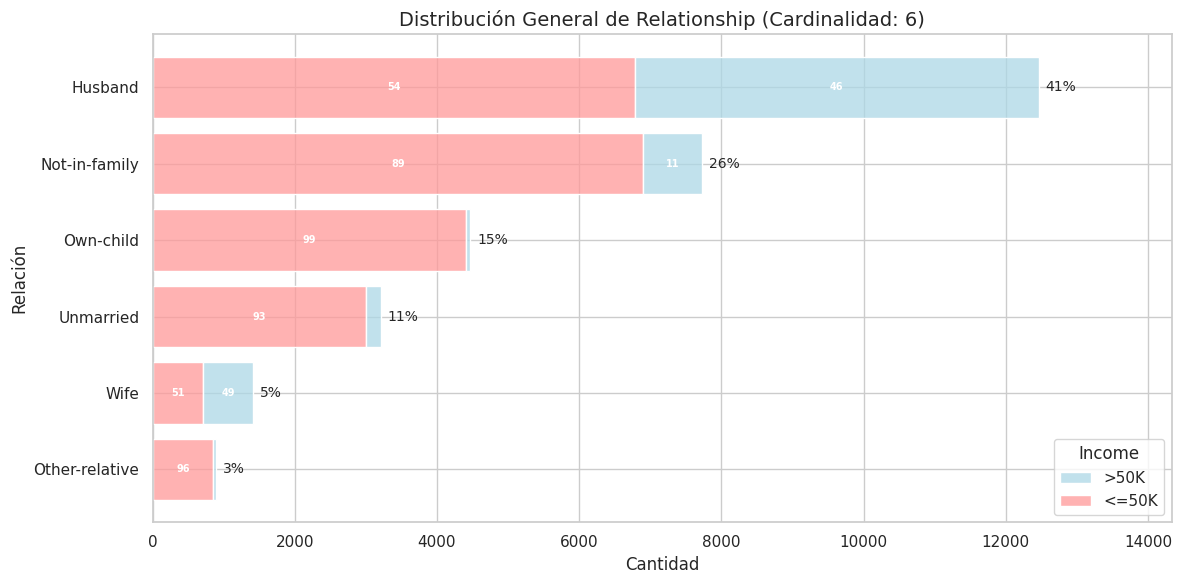

In [19]:
cardinalidad_rel = train['relationship'].nunique()
conteo_rel = train['relationship'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico
train['relationship'] = pd.Categorical(train['relationship'], categories=conteo_rel.index, ordered=True)

sns.histplot(data=train, y='relationship', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Relationship (Cardinalidad: {cardinalidad_rel})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Relación', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_rel.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_rel):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.set_yticks(range(len(conteo_rel)))
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_rel.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['relationship'] = train['relationship'].astype(object)
plt.tight_layout()
plt.show()


- Dado que observamos que categorías como `Husband` o `Wife` tienen una tasa de éxito (ingresos >50K) mucho mayor, utilizaremos **Target Encoding**. Esto permite al modelo conocer la probabilidad histórica de cada rol familiar directamente en una sola variable numérica.

In [20]:
# 1. Calculamos la tasa de 'buenos' (>50K) por categoría en el set de entrenamiento
target_mean_rel = TAR_income_train.groupby(train['relationship']).mean().to_dict()

# 2. Mapeamos a los datasets
# Renombramos a AVG_relationship según lo solicitado
AVG_relationship_train = train['relationship'].map(target_mean_rel)
AVG_relationship_test = test['relationship'].map(target_mean_rel)

# Manejo de nulos en test con la media global de entrenamiento
global_mean = TAR_income_train.mean()
AVG_relationship_test = AVG_relationship_test.fillna(global_mean)

# Nombramos la serie
AVG_relationship_train.name = 'AVG_relationship'
AVG_relationship_test.name = 'AVG_relationship'

print("Probabilidad de >50K por categoría (Mapeada a AVG_relationship):")
for rel, prob in sorted(target_mean_rel.items(), key=lambda x: x[1], reverse=True):
    print(f" - {rel}: {prob:.2%}")

display(AVG_relationship_train.to_frame().head())

Probabilidad de >50K por categoría (Mapeada a AVG_relationship):
 - Wife: 49.36%
 - Husband: 45.57%
 - Not-in-family: 10.65%
 - Unmarried: 6.63%
 - Other-relative: 3.94%
 - Own-child: 1.43%


,AVG_relationship
0,0.106523
1,0.455669
2,0.106523
3,0.455669
4,0.493599


### Race
Autoidentificación racial del individuo.

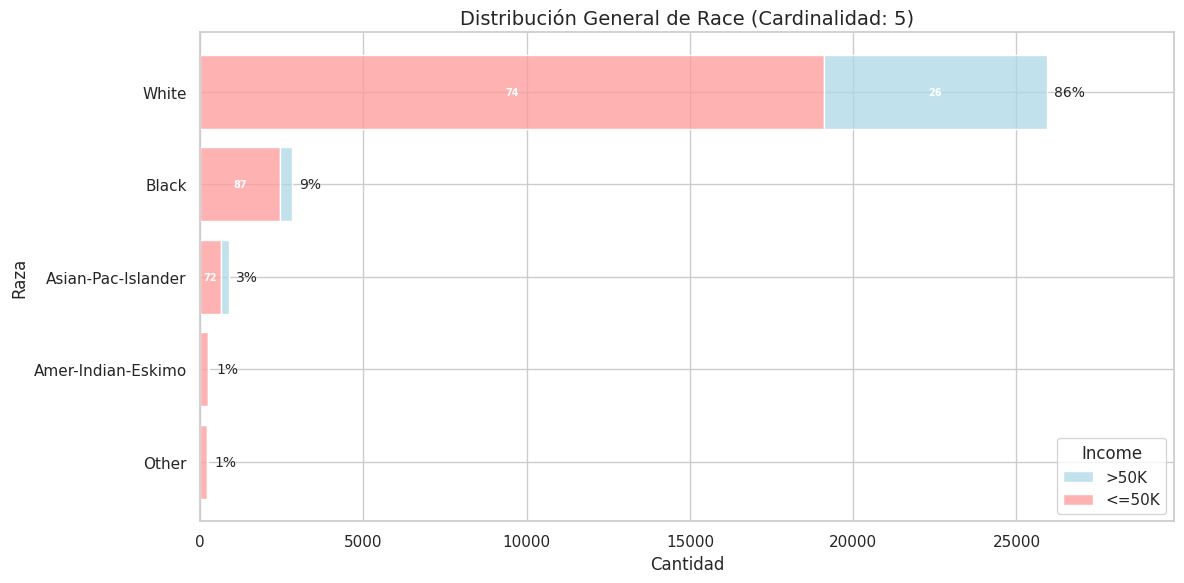

In [21]:
cardinalidad_race = train['race'].nunique()
conteo_race = train['race'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico
train['race'] = pd.Categorical(train['race'], categories=conteo_race.index, ordered=True)

sns.histplot(data=train, y='race', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Race (Cardinalidad: {cardinalidad_race})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Raza', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_race.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_race):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_race):
            total_bar = conteo_race.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['race'] = train['race'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 6
- Agrupar por Otros?

In [22]:
from sklearn.preprocessing import OneHotEncoder

# 1. Definimos las categorías principales y agrupamos las demás en 'Other'
main_races = ['White', 'Black', 'Asian-Pac-Islander']

train['race_grouped'] = train['race'].apply(lambda x: x if x in main_races else 'Other')
test['race_grouped'] = test['race'].apply(lambda x: x if x in main_races else 'Other')

# 2. Aplicamos One-Hot Encoding a las categorías agrupadas
ohe_race = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

race_ohe_train_raw = ohe_race.fit_transform(train[['race_grouped']])
race_ohe_test_raw = ohe_race.transform(test[['race_grouped']])

# Nombres de columnas limpios
columns_ohe_race = [f"OHE_race_{cat.replace(' ', '_').replace('-', '_')}" for cat in ohe_race.categories_[0]]

# Crear DataFrames
OHE_race_train = pd.DataFrame(race_ohe_train_raw, columns=columns_ohe_race, index=train.index)
OHE_race_test = pd.DataFrame(race_ohe_test_raw, columns=columns_ohe_race, index=test.index)

print(f"Race procesada (agrupada en {len(columns_ohe_race)} categorías):")
display(OHE_race_train.head())

Race procesada (agrupada en 4 categorías):


,OHE_race_Asian_Pac_Islander,OHE_race_Black,OHE_race_Other,OHE_race_White
0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0


In [23]:
def check_is_white(race_val):
    return 1 if 'White' in race_val else 0

BOOL_is_white_train = train['race'].apply(check_is_white)
BOOL_is_white_test = test['race'].apply(check_is_white)

BOOL_is_white_train.name = 'BOOL_is_white'
BOOL_is_white_test.name = 'BOOL_is_white'

print("Variable 'BOOL_is_white' creada.")
print(f"Distribución en Train:\n{BOOL_is_white_train.value_counts(normalize=True)}")
display(BOOL_is_white_train.to_frame().head())

Variable 'BOOL_is_white' creada.
Distribución en Train:
BOOL_is_white
1    0.85979
0    0.14021
Name: proportion, dtype: float64


,BOOL_is_white
0,1
1,1
2,1
3,0
4,0


### Sex
Sexo biológico del individuo (masculino o femenino).

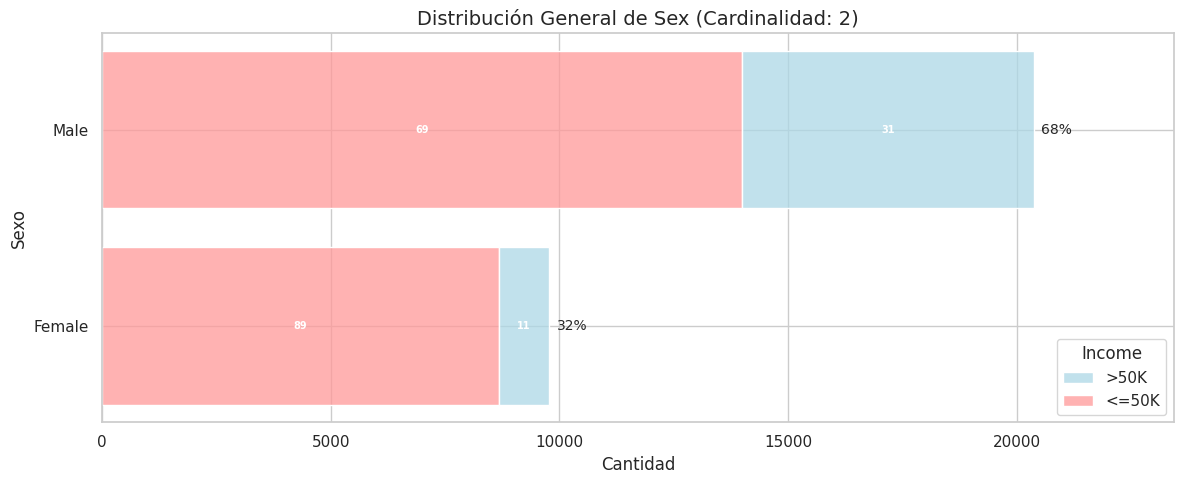

In [24]:
cardinalidad_sex = train['sex'].nunique()
conteo_sex = train['sex'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['sex'] = pd.Categorical(train['sex'], categories=conteo_sex.index, ordered=True)

sns.histplot(data=train, y='sex', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Sex (Cardinalidad: {cardinalidad_sex})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Sexo', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_sex.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_sex):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_sex):
            total_bar = conteo_sex.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['sex'] = train['sex'].astype(object)
plt.tight_layout()
plt.show()

#### Transformación de Sex
Al ser una variable binaria, aplicaremos un mapeo simple a 0 y 1. Esto permite que el modelo asimile la información en una sola dimensión numérica.

In [25]:
# 8. Transformación Sex -> BOOL_is_men
sex_mapping = {'Male': 1, 'Female': 0}

BOOL_is_men_train = train['sex'].map(sex_mapping).astype(int)
BOOL_is_men_test = test['sex'].map(sex_mapping).astype(int)

# Asignamos nombre para consistencia
BOOL_is_men_train.name = 'BOOL_is_men'
BOOL_is_men_test.name = 'BOOL_is_men'

print(f"Variable 'BOOL_is_men' creada: 1 para Male y 0 para Female.")
display(BOOL_is_men_train.to_frame().head())

Variable 'BOOL_is_men' creada: 1 para Male y 0 para Female.


,BOOL_is_men
0,1
1,1
2,1
3,1
4,0


### Skill-profile
Habilidad principal o conocimiento técnico adquirido que podría aplicar en el trabajo.

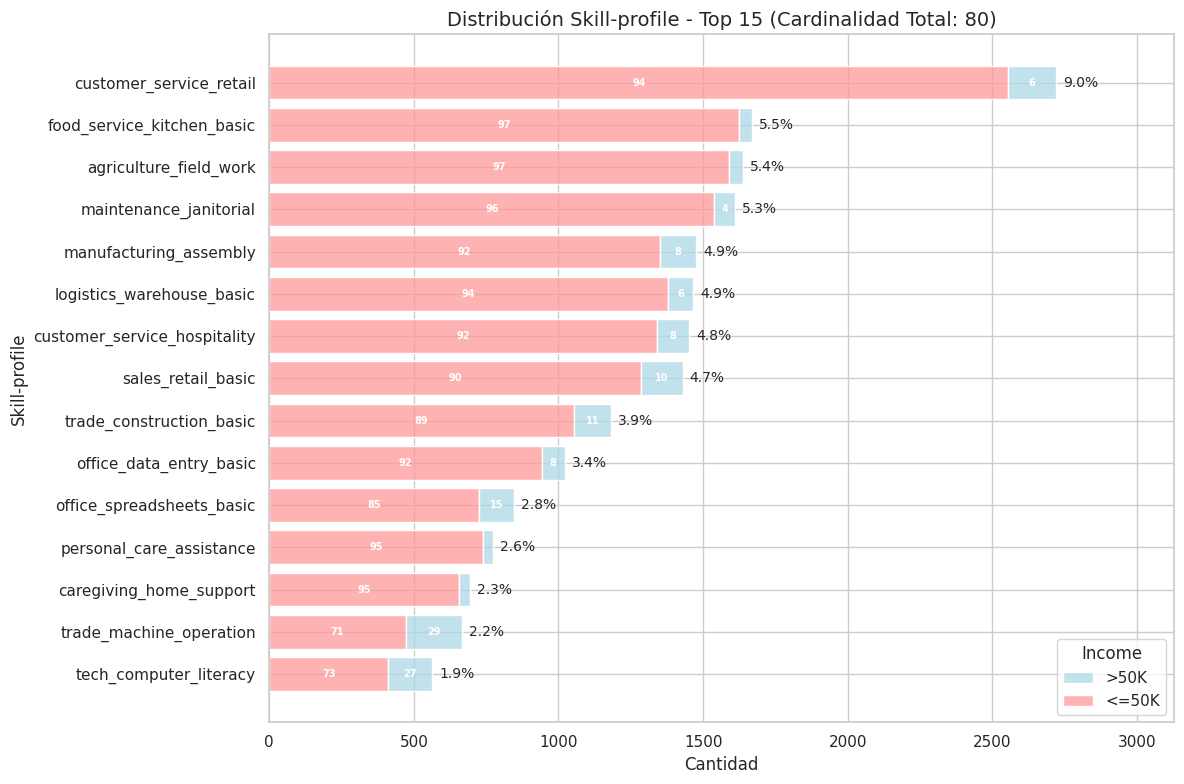

In [26]:
cardinalidad_skill = train['skill-profile'].nunique()
conteo_skill = train['skill-profile'].value_counts()
top_15_skills = conteo_skill.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
train_top = train[train['skill-profile'].isin(top_15_skills.index)].copy()
train_top['skill-profile'] = pd.Categorical(train_top['skill-profile'], categories=top_15_skills.index, ordered=True)

sns.histplot(data=train_top, y='skill-profile', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución Skill-profile - Top 15 (Cardinalidad Total: {cardinalidad_skill})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Skill-profile', fontsize=12)

sns.move_legend(ax, "lower right", title='Income')

ax.set_xlim(0, top_15_skills.max() * 1.15)
total_len = len(train)
for i, width in enumerate(top_15_skills):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(top_15_skills):
            total_bar = top_15_skills.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

- Cardinalidad de 80, Embeddings

In [27]:
# 10. Transformación Skill-profile -> FRE_skill_profile
# Cardinalidad 80: Utilizamos Frequency Encoding

# 1. Calculamos las frecuencias en entrenamiento
skill_freq_map = train['skill-profile'].value_counts(normalize=True).to_dict()

# 2. Mapeamos a ambos datasets
FRE_skill_profile_train = train['skill-profile'].map(skill_freq_map)
FRE_skill_profile_test = test['skill-profile'].map(skill_freq_map)

# Manejo de nulos en test (categorías que no estaban en train) con 0
FRE_skill_profile_test = FRE_skill_profile_test.fillna(0)

# Convertimos a Series con nombre
FRE_skill_profile_train.name = 'FRE_skill_profile'
FRE_skill_profile_test.name = 'FRE_skill_profile'

print(f"Frequency Encoding aplicado a 'skill-profile'.")
print(f"Ejemplo de mapeo (Top 5 habilidades):")
for skill, freq in list(skill_freq_map.items())[:5]:
    print(f" - {skill}: {freq:.4f}")

display(FRE_skill_profile_train.to_frame().head())

Frequency Encoding aplicado a 'skill-profile'.
Ejemplo de mapeo (Top 5 habilidades):
 - customer_service_retail: 0.0902
 - food_service_kitchen_basic: 0.0553
 - agriculture_field_work: 0.0543
 - maintenance_janitorial: 0.0534
 - manufacturing_assembly: 0.0489


,FRE_skill_profile
0,0.048936
1,0.009548
2,0.054307
3,0.033851
4,0.005338


### Native-country
País de nacimiento del individuo.

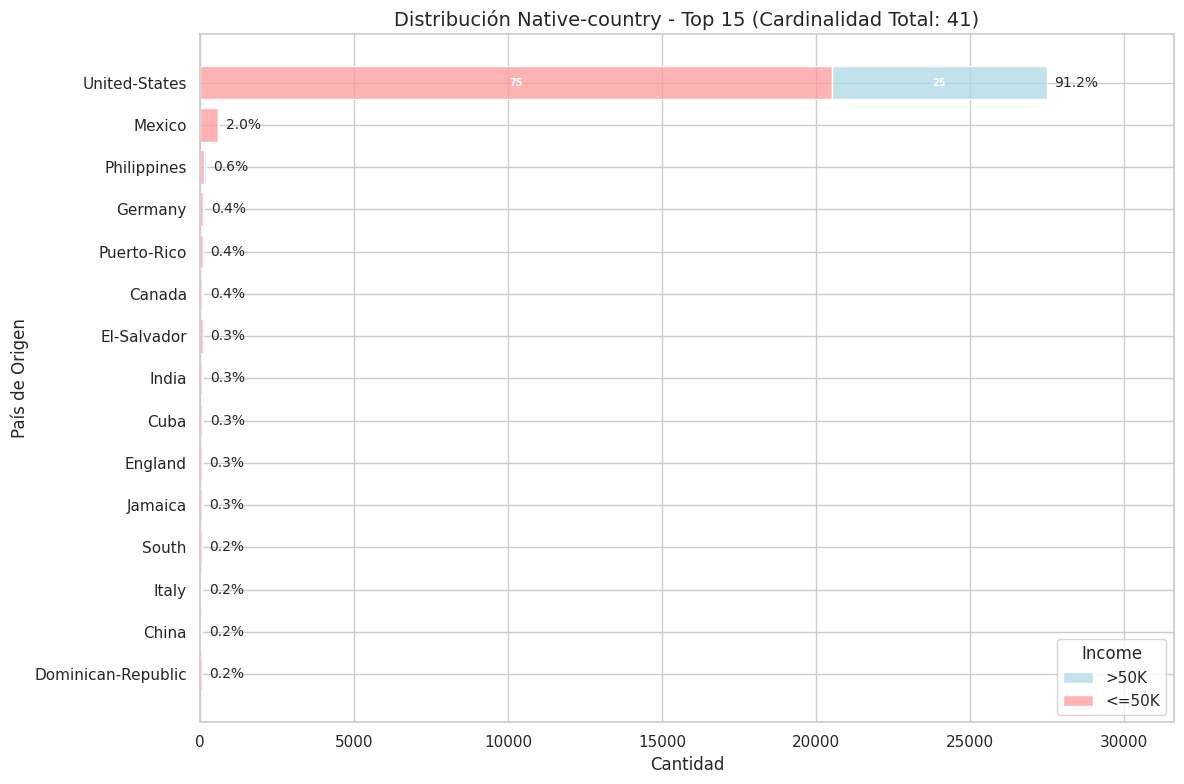

In [28]:
cardinalidad_country = train['native-country'].nunique()
conteo_country = train['native-country'].value_counts()
top_15_countries = conteo_country.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
train_top_c = train[train['native-country'].isin(top_15_countries.index)].copy()
train_top_c['native-country'] = pd.Categorical(train_top_c['native-country'], categories=top_15_countries.index, ordered=True)

sns.histplot(data=train_top_c, y='native-country', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución Native-country - Top 15 (Cardinalidad Total: {cardinalidad_country})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('País de Origen', fontsize=12)

sns.move_legend(ax, "lower right", title='Income')

ax.set_xlim(0, top_15_countries.max() * 1.15)
total_len = len(train)
for i, width in enumerate(top_15_countries):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(top_15_countries):
            total_bar = top_15_countries.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

- Cardinalidad de 41, pero casi todos solo en 3 o 4 clases. Pensarlo

In [29]:
# 11. Transformación Native-country -> BOOL_is_usa
# Simplificación binaria debido al fuerte desbalance hacia USA

def check_is_usa(country):
    return 1 if country.strip() == 'United-States' else 0

BOOL_is_usa_train = train['native-country'].apply(check_is_usa)
BOOL_is_usa_test = test['native-country'].apply(check_is_usa)

# Asignamos nombres para consistencia
BOOL_is_usa_train.name = 'BOOL_is_usa'
BOOL_is_usa_test.name = 'BOOL_is_usa'

print(f"Variable 'BOOL_is_usa' creada.")
print(f"Distribución en Train:\n{BOOL_is_usa_train.value_counts(normalize=True)}")
display(BOOL_is_usa_train.to_frame().head())

Variable 'BOOL_is_usa' creada.
Distribución en Train:
BOOL_is_usa
1    0.911876
0    0.088124
Name: proportion, dtype: float64


,BOOL_is_usa
0,1
1,1
2,1
3,1
4,0


### Hours-per-week
Cantidad de horas trabajadas por semana (variable numérica).

Estadísticas descriptivas de la variable 'hours-per-week':


,hours-per-week
count,30162.000000
mean,40.931238
std,11.979984
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


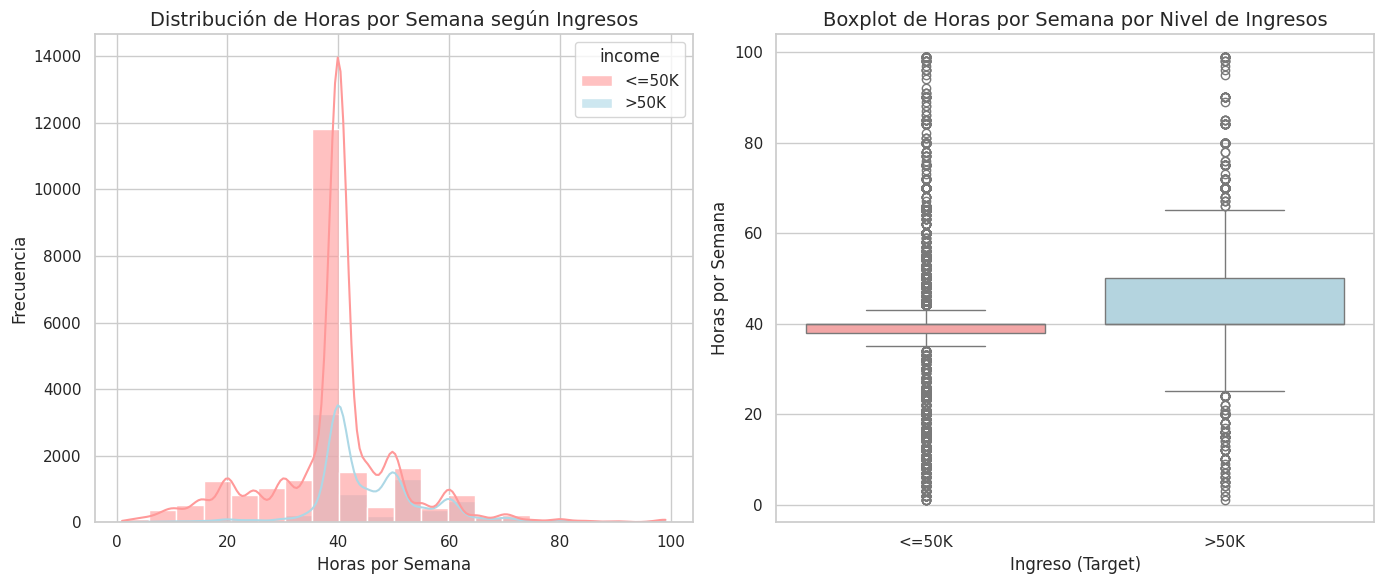

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mostrar estadísticas descriptivas de la variable 'hours-per-week'
print("Estadísticas descriptivas de la variable 'hours-per-week':")
display(train['hours-per-week'].describe())

# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='hours-per-week', hue='income', bins=20, kde=True, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Horas por Semana según Ingresos', fontsize=14)
axes[0].set_xlabel('Horas por Semana', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Horas por Semana por clase (Income)
sns.boxplot(data=train, x='income', y='hours-per-week', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Horas por Semana por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Horas por Semana', fontsize=12)

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd

# 9. Transformación Hours-per-week -> Binning manual
# Definimos los rangos: Part-time (<35), Full-time (35-45), Over-time (>45)
def bin_hours(h):
    if h < 35:
        return 'Part-time'
    elif 35 <= h <= 45:
        return 'Full-time'
    else:
        return 'Over-time'

train['hours_binned'] = train['hours-per-week'].apply(bin_hours)
test['hours_binned'] = test['hours-per-week'].apply(bin_hours)

print("Distribución de las nuevas categorías de horas (Train):")
display(train['hours_binned'].value_counts())


Distribución de las nuevas categorías de horas (Train):


,count
hours_binned,
Full-time,18630
Over-time,6842
Part-time,4690


In [32]:
from sklearn.preprocessing import OrdinalEncoder

# Aplicamos Ordinal Encoding manteniendo el orden lógico
# Definimos el orden explícito: Part-time (0) < Full-time (1) < Over-time (2)
hours_categories = [['Part-time', 'Full-time', 'Over-time']]
encoder_hours = OrdinalEncoder(categories=hours_categories)

ORD_hours_train = pd.Series(
    encoder_hours.fit_transform(train[['hours_binned']]).flatten(),
    index=train.index,
    name='ORD_hours_per_week'
)

ORD_hours_test = pd.Series(
    encoder_hours.transform(test[['hours_binned']]).flatten(),
    index=test.index,
    name='ORD_hours_per_week'
)

print("Series 'ORD_hours_per_week' creadas exitosamente.")
display(ORD_hours_train.to_frame().head())


Series 'ORD_hours_per_week' creadas exitosamente.


,ORD_hours_per_week
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0


- Poca dispersion
- Pasarla a Ordinal?

### Capital-gain
Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

Estadísticas descriptivas de la variable 'capital-gain':


,capital-gain
count,30162.000000
mean,1092.007858
std,7406.346497
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000



Cantidad de registros con capital-gain igual a 0: 27624
Porcentaje de registros con capital-gain igual a 0: 91.59%



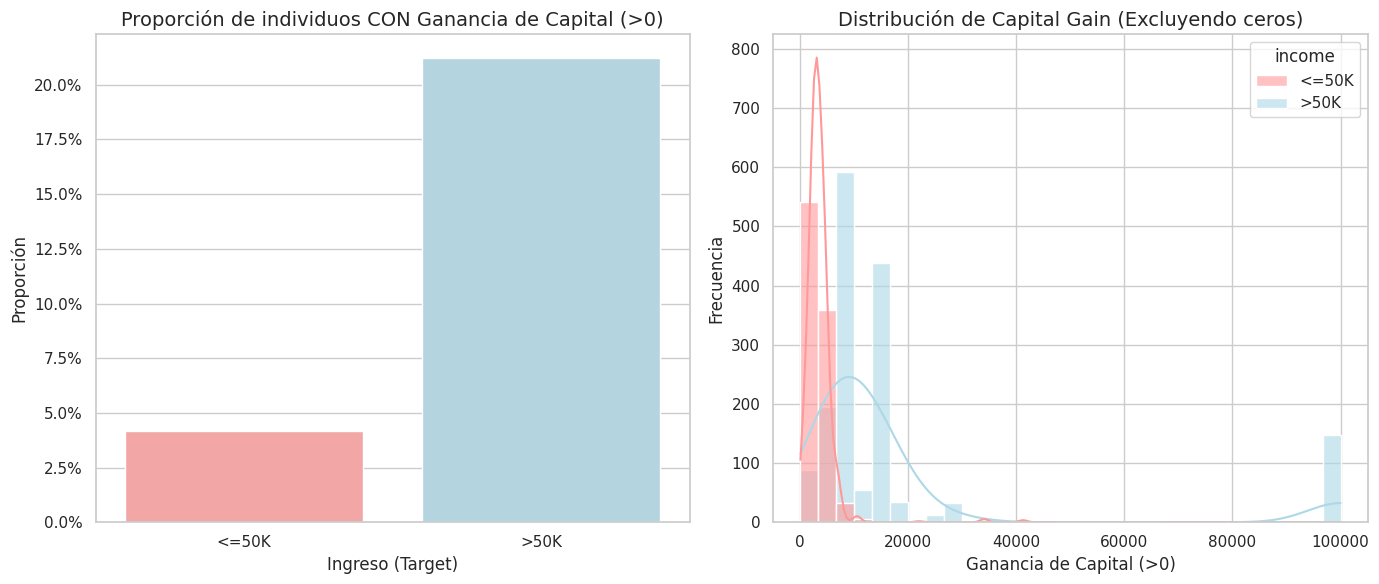

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

print("Estadísticas descriptivas de la variable 'capital-gain':")
display(train['capital-gain'].describe())

zeros_count = (train['capital-gain'] == 0).sum()
total_count = len(train)
zeros_pct = (zeros_count / total_count) * 100

print(f"\nCantidad de registros con capital-gain igual a 0: {zeros_count}")
print(f"Porcentaje de registros con capital-gain igual a 0: {zeros_pct:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train['has_capital_gain'] = train['capital-gain'] > 0

sns.barplot(data=train, x='income', y='has_capital_gain', hue='income', palette=custom_palette, ax=axes[0], errorbar=None, legend=False)
axes[0].set_title('Proporción de individuos CON Ganancia de Capital (>0)', fontsize=14)
axes[0].set_xlabel('Ingreso (Target)', fontsize=12)
axes[0].set_ylabel('Proporción', fontsize=12)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

non_zero_gains = train[train['capital-gain'] > 0]
sns.histplot(data=non_zero_gains, x='capital-gain', hue='income', bins=30, kde=True, ax=axes[1], palette=custom_palette, alpha=0.6)
axes[1].set_title('Distribución de Capital Gain (Excluyendo ceros)', fontsize=14)
axes[1].set_xlabel('Ganancia de Capital (>0)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()

train = train.drop(columns=['has_capital_gain'])

- **Observaciones sobre Capital-gain:** La inmensa mayoría de los registros tienen valor 0. Los valores altos (outliers positivos) parecen tener una fuerte relación con la clase de ingresos altos (>50K). Al ser numérica y muy sesgada, convendrá aplicar una normalización (como MinMax o RobustScaler) antes de pasarla al modelo.

### Tratamiento de Capital Gain
Implementamos una estrategia dual:
1. **BOOL_has_capital_gain**: Indicador binario (1 si tiene ganancia, 0 si no).
2. **NUM_capital_gain**: Valor numérico escalado mediante `RobustScaler` para manejar el sesgo y los outliers.

In [34]:
from sklearn.preprocessing import RobustScaler

# 1. Crear indicador binario con el nombre solicitado
BOOL_has_capital_gain_train = (train['capital-gain'] > 0).astype(int)
BOOL_has_capital_gain_test = (test['capital-gain'] > 0).astype(int)

BOOL_has_capital_gain_train.name = 'BOOL_has_capital_gain'
BOOL_has_capital_gain_test.name = 'BOOL_has_capital_gain'

# 2. Escalado de la magnitud numérica
scaler_gain = RobustScaler()

SCA_capital_gain_train = pd.Series(
    scaler_gain.fit_transform(train[['capital-gain']]).flatten(),
    index=train.index,
    name='SCA_capital_gain'
)

SCA_capital_gain_test = pd.Series(
    scaler_gain.transform(test[['capital-gain']]).flatten(),
    index=test.index,
    name='SCA_capital_gain'
)

print("Variables 'BOOL_has_capital_gain' y 'SCA_capital_gain' creadas.")
display(SCA_capital_gain_train.to_frame().head())

Variables 'BOOL_has_capital_gain' y 'SCA_capital_gain' creadas.


,SCA_capital_gain
0,2174.0
1,0.0
2,0.0
3,0.0
4,0.0


### Capital-loss
Pérdidas declaradas por capital.

Estadísticas descriptivas de la variable 'capital-loss':


,capital-loss
count,30162.000000
mean,88.372489
std,404.298370
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4356.000000



Cantidad de registros con capital-loss igual a 0: 28735
Porcentaje de registros con capital-loss igual a 0: 95.27%



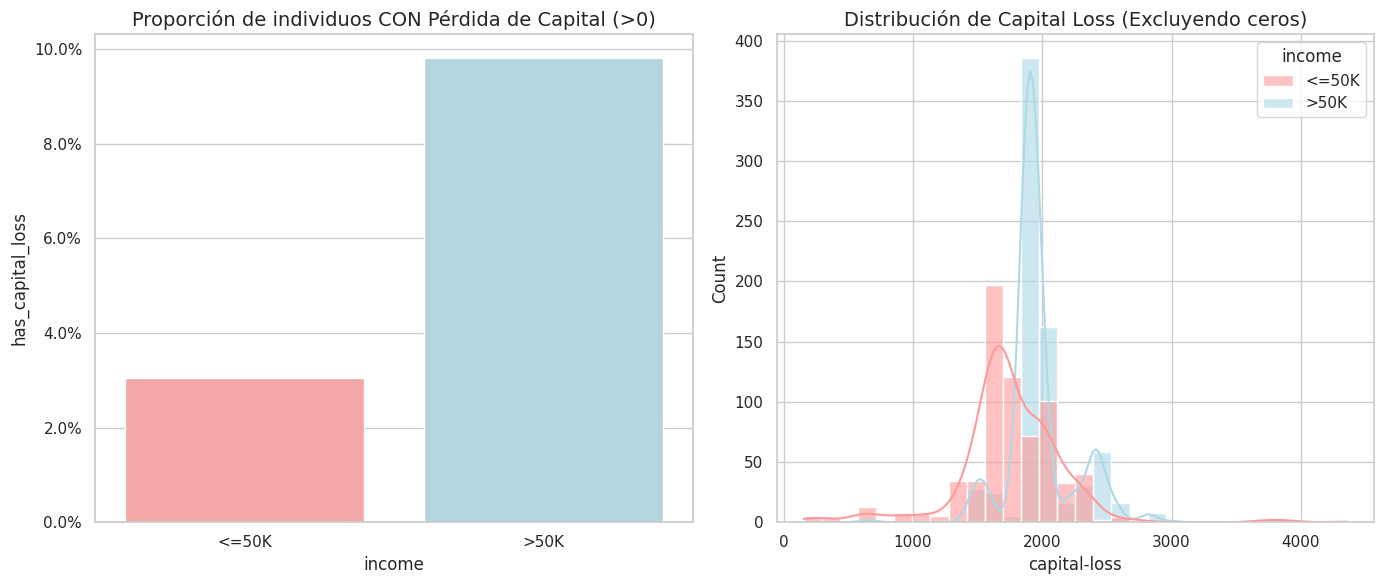

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

print("Estadísticas descriptivas de la variable 'capital-loss':")
display(train['capital-loss'].describe())

# Conteo de ceros
zeros_loss_count = (train['capital-loss'] == 0).sum()
total_count = len(train)
zeros_loss_pct = (zeros_loss_count / total_count) * 100

print(f"\nCantidad de registros con capital-loss igual a 0: {zeros_loss_count}")
print(f"Porcentaje de registros con capital-loss igual a 0: {zeros_loss_pct:.2f}%\n")

# Configurar la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Proporción de individuos con pérdida
train['has_capital_loss'] = train['capital-loss'] > 0
sns.barplot(data=train, x='income', y='has_capital_loss', hue='income', palette=custom_palette, ax=axes[0], errorbar=None, legend=False)
axes[0].set_title('Proporción de individuos CON Pérdida de Capital (>0)', fontsize=14)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 2. Histograma de los que sí tienen pérdida (excluyendo ceros)
non_zero_loss = train[train['capital-loss'] > 0]
sns.histplot(data=non_zero_loss, x='capital-loss', hue='income', bins=30, kde=True, ax=axes[1], palette=custom_palette, alpha=0.6)
axes[1].set_title('Distribución de Capital Loss (Excluyendo ceros)', fontsize=14)

plt.tight_layout()
plt.show()

train = train.drop(columns=['has_capital_loss'])

- **Observaciones sobre Capital-loss:** De manera similar a `capital-gain`, la mayoría de los individuos no registran pérdidas de capital (valor 0). Sin embargo, se observan algunos outliers en ambos grupos de ingresos. Al igual que las otras numéricas, será conveniente aplicarle un escalado (como MinMax o RobustScaler) para que el modelo la asimile correctamente.

In [36]:
from sklearn.preprocessing import RobustScaler

# 1. Crear indicador binario para pérdidas
BOOL_has_capital_loss_train = (train['capital-loss'] > 0).astype(int)
BOOL_has_capital_loss_test = (test['capital-loss'] > 0).astype(int)

BOOL_has_capital_loss_train.name = 'BOOL_has_capital_loss'
BOOL_has_capital_loss_test.name = 'BOOL_has_capital_loss'

# 2. Escalado robusto de la magnitud (SCA_capital_loss)
scaler_loss = RobustScaler()

SCA_capital_loss_train = pd.Series(
    scaler_loss.fit_transform(train[['capital-loss']]).flatten(),
    index=train.index,
    name='SCA_capital_loss'
)

SCA_capital_loss_test = pd.Series(
    scaler_loss.transform(test[['capital-loss']]).flatten(),
    index=test.index,
    name='SCA_capital_loss'
)

print("Variables 'BOOL_has_capital_loss' y 'SCA_capital_loss' creadas con éxito.")
display(SCA_capital_loss_train.describe())

Variables 'BOOL_has_capital_loss' y 'SCA_capital_loss' creadas con éxito.


,SCA_capital_loss
count,30162.000000
mean,88.372489
std,404.298370
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4356.000000


### Baseline

### Consolidación Final de Variables (30 features)

En esta sección unificamos todas las transformaciones realizadas anteriormente para obtener los datasets `X_train` y `X_test` finales, asegurando que los nombres de las columnas sigan las convenciones acordadas (`SCA_`, `BOOL_`, `NUM_`, `ORD_`, `OHE_`).

In [37]:
import pandas as pd

# Lista de componentes para concatenar (Entrenamiento)
features_list_train = [
    SCA_age_train,               # 1
    BOOL_is_men_train,           # 1
    AVG_relationship_train,      # 1
    FRE_occupation_train,        # 1
    FRE_skill_profile_train,     # 1
    BOOL_is_usa_train,           # 1
    BOOL_is_white_train,         # 1 (Nueva)
    BOOL_has_capital_gain_train, # 1
    SCA_capital_gain_train,      # 1
    BOOL_has_capital_loss_train, # 1
    SCA_capital_loss_train,      # 1
    ORD_education_train,         # 1
    ORD_hours_train,             # 1
    OHE_workclass_train,         # 7
    OHE_marital_train,           # 7
    OHE_race_train               # 4
]

# Lista de componentes para concatenar (Test)
features_list_test = [
    SCA_age_test,
    BOOL_is_men_test,
    AVG_relationship_test,
    FRE_occupation_test,
    FRE_skill_profile_test,
    BOOL_is_usa_test,
    BOOL_is_white_test,
    BOOL_has_capital_gain_test,
    SCA_capital_gain_test,
    BOOL_has_capital_loss_test,
    SCA_capital_loss_test,
    ORD_education_test,
    ORD_hours_test,
    OHE_workclass_test,
    OHE_marital_test,
    OHE_race_test
]

# Creación de los DataFrames finales
X_train = pd.concat(features_list_train, axis=1)
X_test = pd.concat(features_list_test, axis=1)
y_train = TAR_income_train
y_test = TAR_income_test

# Verificación de nombres y cantidad de columnas
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Total de features: {X_train.shape[1]}")
display(X_train.head())

Dimensiones de X_train: (30162, 31)
Total de features: 31


,SCA_age,BOOL_is_men,AVG_relationship,FRE_occupation,FRE_skill_profile,BOOL_is_usa,BOOL_is_white,BOOL_has_capital_gain,SCA_capital_gain,BOOL_has_capital_loss,...,OHE_Married-AF-spouse,OHE_Married-civ-spouse,OHE_Married-spouse-absent,OHE_Never-married,OHE_Separated,OHE_Widowed,OHE_race_Asian_Pac_Islander,OHE_race_Black,OHE_race_Other,OHE_race_White
0,0.400000,1,0.106523,0.123367,0.048936,1,1,1,2174.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.600000,1,0.455669,0.132352,0.009548,1,1,0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.381818,1,0.106523,0.044758,0.054307,1,1,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.654545,1,0.455669,0.044758,0.033851,1,0,0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.200000,0,0.493599,0.133877,0.005338,0,0,0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [38]:
# 12. Consolidación Final de Features (X_train, X_test) - Actualizado con Race completa

X_train = pd.concat([
    SCA_age_train,               # 1
    BOOL_is_men_train,           # 1
    AVG_relationship_train,      # 1
    FRE_occupation_train,        # 1
    FRE_skill_profile_train,     # 1
    BOOL_is_usa_train,           # 1
    BOOL_has_capital_gain_train, # 1
    SCA_capital_gain_train,      # 1
    BOOL_has_capital_loss_train, # 1
    SCA_capital_loss_train,      # 1
    ORD_education_train,         # 1
    ORD_hours_train,             # 1
    OHE_workclass_train,         # 7
    OHE_marital_train,           # 7
    OHE_race_train               # 5 (Antes eran 4)
], axis=1)

X_test = pd.concat([
    SCA_age_test,
    BOOL_is_men_test,
    AVG_relationship_test,
    FRE_occupation_test,
    FRE_skill_profile_test,
    BOOL_is_usa_test,
    BOOL_has_capital_gain_test,
    SCA_capital_gain_test,
    BOOL_has_capital_loss_test,
    SCA_capital_loss_test,
    ORD_education_test,
    ORD_hours_test,
    OHE_workclass_test,
    OHE_marital_test,
    OHE_race_test
], axis=1)

y_train = TAR_income_train
y_test = TAR_income_test

print(f"Dataset de Entrenamiento Final (X_train): {X_train.shape}")
print(f"Total de features: {X_train.shape[1]}")
display(X_train.head())

Dataset de Entrenamiento Final (X_train): (30162, 30)
Total de features: 30


,SCA_age,BOOL_is_men,AVG_relationship,FRE_occupation,FRE_skill_profile,BOOL_is_usa,BOOL_has_capital_gain,SCA_capital_gain,BOOL_has_capital_loss,SCA_capital_loss,...,OHE_Married-AF-spouse,OHE_Married-civ-spouse,OHE_Married-spouse-absent,OHE_Never-married,OHE_Separated,OHE_Widowed,OHE_race_Asian_Pac_Islander,OHE_race_Black,OHE_race_Other,OHE_race_White
0,0.400000,1,0.106523,0.123367,0.048936,1,1,2174.0,0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.600000,1,0.455669,0.132352,0.009548,1,0,0.0,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.381818,1,0.106523,0.044758,0.054307,1,0,0.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.654545,1,0.455669,0.044758,0.033851,1,0,0.0,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.200000,0,0.493599,0.133877,0.005338,0,0,0.0,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [39]:
# 12. Consolidación Final de Features (X_train, X_test) - Actualizado con is_white

X_train = pd.concat([
    SCA_age_train,               # 1
    BOOL_is_men_train,           # 1
    AVG_relationship_train,      # 1
    FRE_occupation_train,        # 1
    FRE_skill_profile_train,     # 1
    BOOL_is_usa_train,           # 1
    BOOL_is_white_train,         # 1 (Nueva)
    BOOL_has_capital_gain_train, # 1
    SCA_capital_gain_train,      # 1
    BOOL_has_capital_loss_train, # 1
    SCA_capital_loss_train,      # 1
    ORD_education_train,         # 1
    ORD_hours_train,             # 1
    OHE_workclass_train,         # 7
    OHE_marital_train,           # 7
    OHE_race_train               # 5
], axis=1)

X_test = pd.concat([
    SCA_age_test,
    BOOL_is_men_test,
    AVG_relationship_test,
    FRE_occupation_test,
    FRE_skill_profile_test,
    BOOL_is_usa_test,
    BOOL_is_white_test,
    BOOL_has_capital_gain_test,
    SCA_capital_gain_test,
    BOOL_has_capital_loss_test,
    SCA_capital_loss_test,
    ORD_education_test,
    ORD_hours_test,
    OHE_workclass_test,
    OHE_marital_test,
    OHE_race_test
], axis=1)

y_train = TAR_income_train
y_test = TAR_income_test

print(f"Dataset de Entrenamiento Final (X_train): {X_train.shape}")
print(f"Total de features: {X_train.shape[1]}")
display(X_train.head())

Dataset de Entrenamiento Final (X_train): (30162, 31)
Total de features: 31


,SCA_age,BOOL_is_men,AVG_relationship,FRE_occupation,FRE_skill_profile,BOOL_is_usa,BOOL_is_white,BOOL_has_capital_gain,SCA_capital_gain,BOOL_has_capital_loss,...,OHE_Married-AF-spouse,OHE_Married-civ-spouse,OHE_Married-spouse-absent,OHE_Never-married,OHE_Separated,OHE_Widowed,OHE_race_Asian_Pac_Islander,OHE_race_Black,OHE_race_Other,OHE_race_White
0,0.400000,1,0.106523,0.123367,0.048936,1,1,1,2174.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.600000,1,0.455669,0.132352,0.009548,1,1,0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.381818,1,0.106523,0.044758,0.054307,1,1,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.654545,1,0.455669,0.044758,0.033851,1,0,0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.200000,0,0.493599,0.133877,0.005338,0,0,0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.